# Importation of libraries

In [1]:
import os
from pathlib import Path

# Run once at the top — sets cwd to Thesis/
os.chdir(Path().resolve().parents[1])  # eda → notebooks → Thesis

In [2]:
# Standard libraries
import pandas as pd

# Non-standard Libaries
from src.utils.data_loaders.bad_debts import BadDebtsExpense

from src.modules.feature_engineering.credit_sales_machine_learning import CreditSalesProcessor
from src.modules.feature_engineering.days_sales_outstanding import DSO
from src.modules.feature_engineering.consecutive_years import get_consecutive_years

from src.modules.exploratory_data_analysis.enrollment_statistics import enrollment_statistics

# B. Loading of datasets

In [3]:
import os
import sys
from pathlib import Path

# Get the notebook's own path — works in VS Code and via Papermill
_nb_path = Path(
    globals().get("__vsc_ipynb_file__")  # VS Code interactive
    or globals().get("__file__")         # Papermill / script
    or __file__                          # fallback
).resolve()

# Walk up until we find 'src/' (thesis root marker)
def _find_root(start: Path, marker="src") -> Path:
    for parent in [start, *start.parents]:
        if (parent / marker).is_dir():
            return parent
    raise FileNotFoundError(f"Could not find root (no '{marker}' folder found above {start})")

_thesis_root = _find_root(_nb_path)

os.chdir(_thesis_root)
if str(_thesis_root) not in sys.path:
    sys.path.insert(0, str(_thesis_root))

print(f"Working directory: {_thesis_root}")

Working directory: C:\Users\rjbel\Python\Notebooks\Mapua\Thesis


In [4]:
from src.utils.data_loaders.read_settings_json import read_settings_json

args = read_settings_json()
args

{'Config': {'debug_mode': 'False', 'TEMP_CACHE': 'data/temp_cache'},
 'TrainingInput': {'CHART_OF_ACCOUNTS': 'data/training_input/chart_of_accounts.xlsx',
  'ENROLLEES': 'data/training_input/enrollees_pseudonymized.xlsx',
  'REVENUES': 'data/training_input/revenues_pseudonymized.xlsx'},
 'Training': {'MODEL_PARAMETERS': 'src/modules/machine_learning/parameters.json',
  'RESULTS_ROOT': 'data/training_results',
  'LOGS': 'data/training_logs',
  'DEPLOYED_MODELS': 'data/training_results/deployed_models',
  'observation_end': '2026/04/24',
  'target_feature': 'dtp_bracket',
  'test_size': '0.30'}}

## 1. Revenues

In [5]:
df_revenues = pd.read_excel(args['TrainingInput']['REVENUES'], engine='calamine')

## 2. Enrollees

In [6]:
df_enrollees = pd.read_excel(args['TrainingInput']['ENROLLEES'], engine='calamine')
df_enrollees

,school_year,student_id_pseudonimized,plan_type,grade_level,enrollment_date,education_level,has_refunded
0,2018,08GNGU9D,Plan - D,G03,2018-06-07,Elementary,No Refund
1,2018,0JWX77BI,Plan - B,SpE,2018-06-07,Special Education,No Refund
2,2018,0LZJ7928,Plan - A,G01,2018-05-18,Elementary,No Refund
3,2018,15RI5SWE,Plan - B,G03,2018-06-06,Elementary,No Refund
4,2018,1IGM0VHQ,Plan - A,G01,2018-05-04,Elementary,No Refund
...,...,...,...,...,...,...,...
2780,2026,Z3FMQ7JI,Plan - A,G05,2026-01-09,Elementary,No Refund
2781,2026,ZDC3I53X,Plan - B,G10,2026-03-30,Junior High,No Refund
2782,2026,ZHRMZVJR,Plan - C,G06,2026-03-16,Elementary,No Refund
2783,2026,ZQB34VX6,Plan - A,SpE,2026-01-20,Special Education,No Refund


In [7]:
df_enrollees = get_consecutive_years(df_enrollees)
df_enrollees[['student_id_pseudonimized','school_year','consecutive_years']]

C:\Users\rjbel\Python\Notebooks\Mapua\Thesis\src\modules\feature_engineering\consecutive_years.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_no_refund = df_no_refund.groupby('student_id_pseudonimized', group_keys=False).apply(compute_streaks)


,student_id_pseudonimized,school_year,consecutive_years
0,08GNGU9D,2018,1.0
1,0JWX77BI,2018,1.0
2,0LZJ7928,2018,1.0
3,15RI5SWE,2018,1.0
4,1IGM0VHQ,2018,1.0
...,...,...,...
2780,Z3FMQ7JI,2026,6.0
2781,ZDC3I53X,2026,9.0
2782,ZHRMZVJR,2026,5.0
2783,ZQB34VX6,2026,4.0


## 3. Credit Sales

In [8]:
cs = CreditSalesProcessor(df_revenues, df_enrollees, args,
                          drop_helper_columns=True,
                          drop_plan_type_columns=True,
                          drop_survival_columns=True,
                          calculate_payment_amounts=True)
df_credit_sales = cs.show_data()

Single due date records:   10580
Multiple due date records: 289


In [9]:
df_credit_sales

,school_year,student_id_pseudonimized,category_name,credit_sale_amount,due_date,prepayments,total_payments,adjusted_credit_amount,net_receivables,dtp_1,...,opening_balance,dtp_bracket,due_month,due_quarter,opening_balance_flag,payment_ratio,early_payer_flag,dtp_rolling_std,dtp_max,plan_type_risk_score
2257,2022,02PNVPI5,Kn2-C-1st,2800.0,2022-09-09,2800.0,2800.0,0.0,0.0,<NA>,...,0.0,on_time,9,3,0,1.034215,NaN,<NA>,<NA>,0
2412,2022,02PNVPI5,Kn2-C-2nd,2800.0,2022-11-05,0.0,0.0,2800.0,2800.0,-3,...,1800.0,None,11,4,1,0.943797,1.0,<NA>,-3,0
2774,2022,02PNVPI5,Kn2-OF-2nd,2267.0,2022-12-05,0.0,0.0,2267.0,2267.0,<NA>,...,4067.0,None,12,4,1,0.881408,NaN,<NA>,-3,0
2971,2022,02PNVPI5,Events - Foundation Day,490.0,2022-12-16,0.0,0.0,490.0,490.0,<NA>,...,7493.0,None,12,4,1,0.805478,NaN,<NA>,-3,0
2972,2022,02PNVPI5,Kn2 - Moving Up - Male,2600.0,2022-12-16,0.0,0.0,2600.0,2600.0,<NA>,...,7493.0,None,12,4,1,0.805478,NaN,<NA>,-3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9792,2025,ZXPL0CI9,G06-C-4th,5800.0,2026-02-06,0.0,5800.0,5800.0,0.0,34,...,5800.0,30_days,2,1,1,0.972245,0.0,10.456258,34,0
9869,2025,ZXPL0CI9,Graduation - Other Services,1500.0,2026-02-18,0.0,1500.0,1500.0,0.0,3,...,1500.0,60_days,2,1,1,0.992873,0.0,14.614491,34,0
9942,2025,ZXPL0CI9,Events - Foundation Day,400.0,2026-03-05,0.0,400.0,400.0,0.0,33,...,1900.0,30_days,3,1,1,0.990990,0.0,15.340578,34,0
9967,2025,ZXPL0CI9,G06-OF-3rd,5800.0,2026-03-06,0.0,5800.0,5800.0,0.0,6,...,7700.0,30_days,3,1,1,0.964462,0.0,16.792856,34,0


## 3. Bad Debts Expense

How BDE is determined:<br>
If previous school year (if current school year is not equal to the max school year of -UE)<br>
AND<br>
if more than 6 months yung ['due date'] vs today()

In [10]:
bde = BadDebtsExpense(df_credit_sales)
df_bde = bde.show_data()
df_bde

,entry_date,due_date,school_year,student_id_pseudonimized,category_name,amount_due,receivables
0,2016-09-27,2016-09-27,2016,2I7BFBKW,Bad Debts Expense,-4526.0,-4526.0
1,2016-09-27,2016-09-27,2016,4WTBDRX6,Bad Debts Expense,-1000.0,-1000.0
2,2016-09-27,2016-09-27,2016,91QRGHW6,Bad Debts Expense,-4640.0,-4640.0
3,2016-09-27,2016-09-27,2016,VO4OVPUC,Bad Debts Expense,-10778.0,-10778.0
4,2016-09-27,2016-09-27,2016,Y19FG15U,Bad Debts Expense,-23751.0,-23751.0
...,...,...,...,...,...,...,...
476,2026-09-09,2026-09-09,2025,5MSL5WQB,Bad Debts Expense,-15000.0,-15000.0
477,2026-09-19,2026-09-19,2025,AUASQNZT,Bad Debts Expense,-400.0,-400.0
478,2026-09-19,2026-09-19,2025,H9CDM057,Bad Debts Expense,-3600.0,-3600.0
479,2026-09-21,2026-09-21,2025,RDT8O2YN,Bad Debts Expense,-2400.0,-2400.0


## 4. Chart of Accounts

In [11]:
df_chart_of_accounts = pd.read_excel(args['TrainingInput']['CHART_OF_ACCOUNTS'], engine='calamine')

In [12]:
df_chart_of_accounts

,strategic_business_unit,account,sub_account,category_name
0,Teaching,Assesment Fees,Regular Fee,Assesment Fee
1,Teaching,Assesment Fees,Special Education,Assesment Fee - SpEd
2,Teaching,Reservation Fees,Regular Fee,Reservation Fee - Regular
3,Teaching,Reservation Fees,Special Education,Reservation Fee - SpEd
4,Teaching,Reservation Fees,Summer,Reservation Fee - Summer
...,...,...,...,...
527,Discounts & Refunds,Discounts,Regular Employee,Discount - Regular Employee
528,Discounts & Refunds,Discounts,Tutorial,Discount - Tutorial
529,Discounts & Refunds,Discounts,Deposit - School Service,Discount - Refundable Deposits
530,Discounts & Refunds,Discounts,Miscellaneous,Discount - Other


## 6. Combined dataframe

In [13]:
# Combine bad debts expense to the revenues
# To recognize receivables no longer able for collection
df_all_transactions = pd.concat((df_revenues, df_bde))


df_all_transactions = pd.merge(
    df_all_transactions,
    df_enrollees,
    on=['student_id_pseudonimized', 'school_year'],
    how='inner'
)

In [14]:
df_all_transactions

,entry_number,entry_date,due_date,school_year,student_id_pseudonimized,category_name,discount_refund_applied_to,amount_due,amount_paid,account_name,receivables,plan_type,grade_level,enrollment_date,education_level,has_refunded,consecutive_years
0,45.0,2018-01-01,2018-01-01,2018,40LHRS6H,Back Account,NaN,39220.0,0.0,Cash,39220.0,Plan - A,SpE,2018-01-10,Special Education,No Refund,1.0
1,47.0,2018-01-01,2018-01-01,2018,8G7SRVR6,Back Account,NaN,23939.0,0.0,Cash,23939.0,Plan - D,G03,2018-06-06,Elementary,No Refund,1.0
2,50.0,2018-01-01,2018-01-01,2018,N9XHXBBF,Back Account,NaN,6000.0,0.0,Cash,6000.0,Plan - C,Kn1,2018-06-08,Pre-Elementary,No Refund,1.0
3,54.0,2018-01-01,2018-01-01,2018,36Q9WATE,Back Account,NaN,324.0,0.0,Cash,324.0,Plan - C,G05,2018-06-04,Elementary,No Refund,1.0
4,55.0,2018-01-01,2018-01-01,2018,GMESTNVP,Back Account,NaN,3505.0,0.0,Cash,3505.0,Plan - C,G02,2018-05-24,Elementary,No Refund,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51653,NaN,2026-09-09,2026-09-09,2025,5MSL5WQB,Bad Debts Expense,NaN,-15000.0,NaN,NaN,-15000.0,Plan - C,G05,2025-05-23,Elementary,No Refund,2.0
51654,NaN,2026-09-19,2026-09-19,2025,AUASQNZT,Bad Debts Expense,NaN,-400.0,NaN,NaN,-400.0,Plan - C,G10,2025-06-30,Junior High,No Refund,1.0
51655,NaN,2026-09-19,2026-09-19,2025,H9CDM057,Bad Debts Expense,NaN,-3600.0,NaN,NaN,-3600.0,Plan - C,G05,2025-05-13,Elementary,No Refund,4.0
51656,NaN,2026-09-21,2026-09-21,2025,RDT8O2YN,Bad Debts Expense,NaN,-2400.0,NaN,NaN,-2400.0,Plan - C,G03,2025-05-31,Elementary,No Refund,4.0


# C. Analysis

## 1. Retention rate

In [15]:
stats = enrollment_statistics(df_enrollees, mode="percent")
stats

,school_year,total_enrolled,new_enrollees_%,1_year_%,2_year_%,3_year_%,4_year_%,5_year_%,6_year_%,7_year_%,8_year_%,9_year_%
0,2018,162,100.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1,2019,290,54.482759,54.482759,45.517241,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
2,2020,150,20.000000,20.666667,34.666667,44.666667,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
3,2021,197,33.502538,39.086294,13.197970,19.289340,28.426396,0.000000,0.000000,0.000000,0.000000,0.0
4,2022,446,58.744395,61.883408,14.573991,4.708520,7.623318,11.210762,0.000000,0.000000,0.000000,0.0
5,2023,477,27.253669,28.092243,45.283019,10.272537,3.144654,4.192872,9.014675,0.000000,0.000000,0.0
6,2024,441,23.356009,24.263039,20.408163,32.653061,8.616780,2.267574,3.854875,7.936508,0.000000,0.0
7,2025,415,18.072289,19.518072,18.072289,18.795181,26.746988,6.506024,1.686747,2.168675,6.506024,0.0
8,2026,180,7.222222,7.777778,12.777778,23.888889,17.222222,22.222222,7.222222,0.555556,3.333333,5.0


In [16]:
stats = enrollment_statistics(df_enrollees, mode="count")
stats

,school_year,total_enrolled,new_enrollees_count,1_year_count,2_year_count,3_year_count,4_year_count,5_year_count,6_year_count,7_year_count,8_year_count,9_year_count
0,2018,162,162,162,0,0,0,0,0,0,0,0
1,2019,290,158,158,132,0,0,0,0,0,0,0
2,2020,150,30,31,52,67,0,0,0,0,0,0
3,2021,197,66,77,26,38,56,0,0,0,0,0
4,2022,446,262,276,65,21,34,50,0,0,0,0
5,2023,477,130,134,216,49,15,20,43,0,0,0
6,2024,441,103,107,90,144,38,10,17,35,0,0
7,2025,415,75,81,75,78,111,27,7,9,27,0
8,2026,180,13,14,23,43,31,40,13,1,6,9


## 2. How long does people with BDE last before leaving?

In [17]:
df_bde_per_sy = (
    df_bde
    .groupby(["school_year"], as_index=False)
    .agg(bad_debts_expense=("amount_due", "sum"))
)
df_bde_per_sy

,school_year,bad_debts_expense
0,2016,-44695.0
1,2017,-62521.0
2,2018,-65095.0
3,2019,-248650.0
4,2020,-7850.0
5,2021,-3450.0
6,2022,-51172.0
7,2023,-260552.0
8,2024,-373806.0
9,2025,-1059821.0


In [18]:
# --- Step 1: Aggregate per school_year + student ---
df_bde_agg = (
    df_bde
    .groupby(["school_year", "student_id_pseudonimized"], as_index=False)
    .agg(bad_debts_expense=("amount_due", "sum"))
)

# --- Step 2: Select only needed columns from df_enrollees ---
df_enr = df_enrollees[["school_year", "student_id_pseudonimized", "consecutive_years"]]

# --- Step 3: Merge aggregated BDE with enrollment info ---
df_merged = pd.merge(
    df_bde_agg,
    df_enr,
    on=["school_year", "student_id_pseudonimized"],
    how="left"   # keeps all BDE records, adds consecutive_years if available
)

In [19]:
# List of students with BDE that were not enrolled or can no longer be reconciled (uses Back Account as the category)
df_merged[df_merged['consecutive_years'].isna()]

,school_year,student_id_pseudonimized,bad_debts_expense,consecutive_years
0,2016,2I7BFBKW,-4526.0,NaN
1,2016,4WTBDRX6,-1000.0,NaN
2,2016,91QRGHW6,-4640.0,NaN
3,2016,VO4OVPUC,-10778.0,NaN
4,2016,Y19FG15U,-23751.0,NaN
5,2017,CATF26JR,-27548.0,NaN
6,2017,JUA8HM1H,-4600.0,NaN
7,2017,QCNXOF71,-30373.0,NaN
8,2018,TUQ59KF9,-4670.0,NaN
12,2019,AT41J5NQ,-28151.0,NaN


In [20]:
# --- Step 1: Aggregate the BDE per school_year and per student_id ---
df_bde_agg = (
    df_bde
    .groupby(["school_year", "student_id_pseudonimized"], as_index=False)
    .agg(bad_debts_expense=("amount_due", "sum"))
)

# --- Step 2: Select only needed columns from df_enrollees ---
df_enr = (
    df_enrollees[["school_year", "student_id_pseudonimized", "consecutive_years"]]
)

# --- Step 3: Merge aggregated BDE with enrollment info ---
df_merged = pd.merge(
    df_bde_agg,
    df_enr,
    on=["school_year", "student_id_pseudonimized"],
    how="left"   # keeps all BDE records, adds consecutive_years if available
)

# --- Step 4: Calculate mean consecutive years per school_year ---
df_mean_consec = (
    df_merged
    .groupby("school_year", as_index=False)
    .agg(mean_consecutive_years=("consecutive_years", "mean"))
)

df_mean_consec

,school_year,mean_consecutive_years
0,2016,NaN
1,2017,NaN
2,2018,1.000000
3,2019,1.142857
4,2020,NaN
5,2021,2.000000
6,2022,1.857143
7,2023,1.875000
8,2024,3.157895
9,2025,3.096154


In [21]:
df_merged['consecutive_years'].mean()

np.float64(2.5727272727272728)

c:\Users\rjbel\anaconda3\envs\Thesis_IPPP\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 5.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


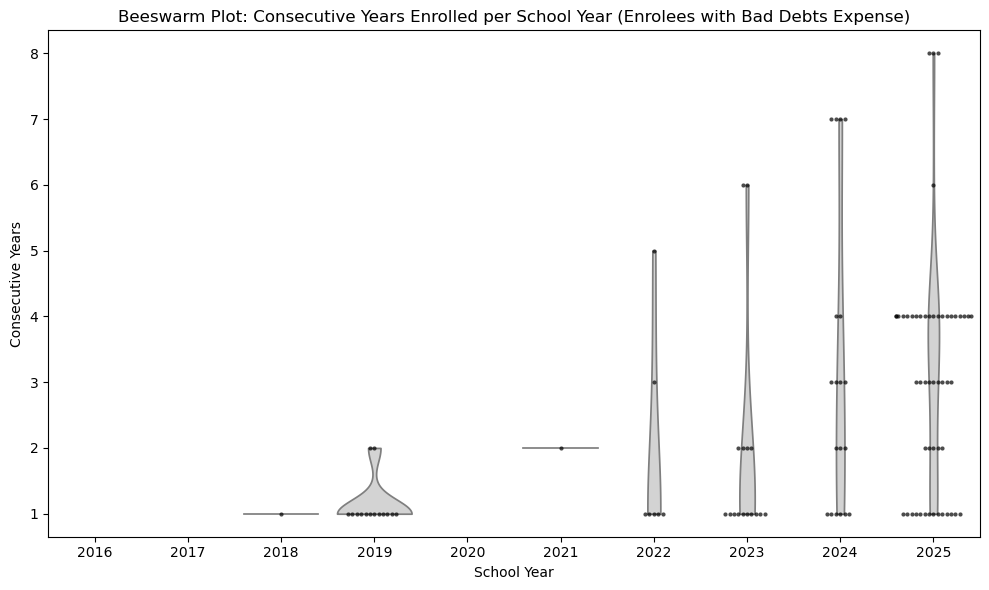

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Base violin plot (distribution shape only, no inner marks)
sns.violinplot(
    data=df_merged,
    x="school_year",
    y="consecutive_years",
    inner=None,   # remove inner bars/points
    color="lightgray",  # neutral background
    cut=0
)

# Overlay swarm plot (the "beeswarm" points)
sns.swarmplot(
    data=df_merged,
    x="school_year",
    y="consecutive_years",
    size=3,   # smaller markers
    alpha=0.7,
    color="black"
)

plt.title("Beeswarm Plot: Consecutive Years Enrolled per School Year (Enrolees with Bad Debts Expense)")
plt.xlabel("School Year")
plt.ylabel("Consecutive Years")
plt.tight_layout()
plt.show()

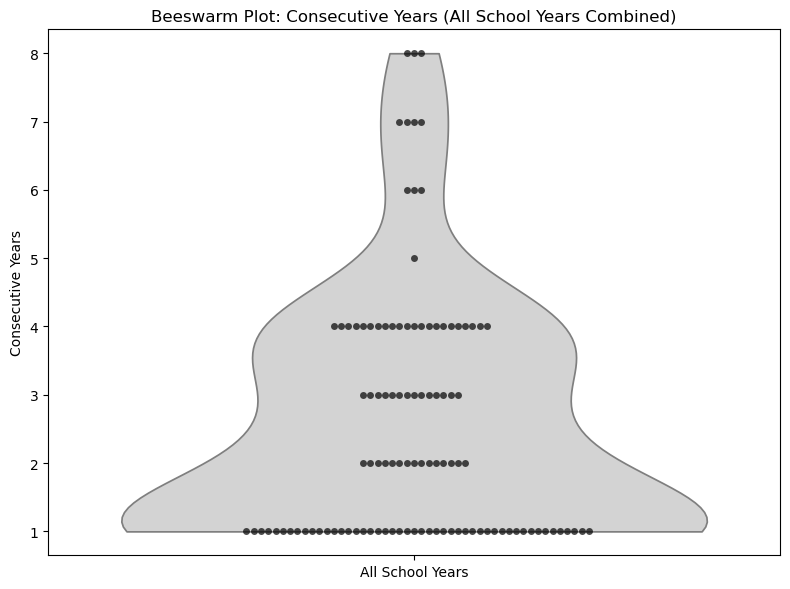

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

# Add a constant category column for clarity
df_merged["all_years"] = "All School Years"

# Base violin plot (distribution shape only, no inner marks)
sns.violinplot(
    data=df_merged,
    x="all_years",
    y="consecutive_years",
    inner=None,        # remove inner bars/points
    color="lightgray", # neutral background
    cut=0
)

# Overlay swarm plot (the "beeswarm" points)
sns.swarmplot(
    data=df_merged,
    x="all_years",
    y="consecutive_years",
    size=5,
    alpha=0.7,
    color="black"
)

plt.title("Beeswarm Plot: Consecutive Years (All School Years Combined)")
plt.xlabel("")  # no need for x-axis label
plt.ylabel("Consecutive Years")
plt.tight_layout()
plt.show()

# Analysis of Days Sales Outstanding (DSO)

$$
DSO = \frac{\text{Average Accounts Receivable}}{\text{Total Credit Sales}} \times \text{Number of Days}
$$

$$
Average Accounts Receivable= \frac{\text{Accounts Receivable, Beginning Balance + Accounts Receivable, Ending Balance}}{\text{2}}
$$

## What is the overall DSO Trend?

In [24]:
dso = DSO(df_all_transactions, df_credit_sales)
df_dso = dso.show_data()
df_dso['year'] = df_dso['date'].dt.year
df_dso['school_year'] = df_dso['year'] -1
df_dso['month'] = df_dso['date'].dt.month

In [25]:
# Filter rows where month == June (6) since July is the end of the enrollment period
df_dso_yearly = df_dso[df_dso['date'].dt.month == 6]
df_dso_yearly[['year', 'school_year', 'rolling_12m_dso']]

,year,school_year,rolling_12m_dso
5,2018,2017,64.103683
17,2019,2018,176.768285
29,2020,2019,88.072298
41,2021,2020,134.862374
53,2022,2021,38.171883
65,2023,2022,53.397324
77,2024,2023,49.730115
89,2025,2024,37.758462
101,2026,2025,38.155359


In [26]:
df_dso.to_excel("DSO.xlsx", index=False)

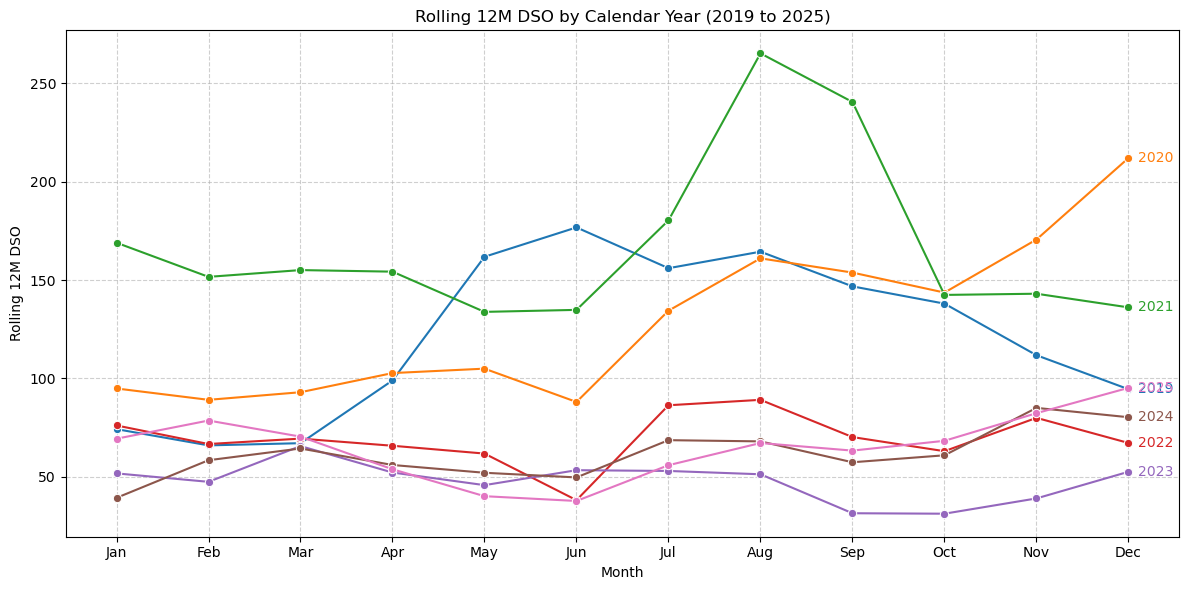

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Filter out 2016, 2017, 2018, 2026
df_plot = df_dso[~df_dso['year'].isin([2016, 2017, 2018, 2026, 2027])]

# Plot with seaborn
plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    data=df_plot,
    x='month',
    y='rolling_12m_dso',
    hue='year',
    marker='o',
    palette='tab10',
    legend=False   # remove legend
)

# Grab the line objects in the same order seaborn plotted them
lines = ax.get_lines()
years = sorted(df_plot['year'].unique())  # ensure consistent ordering

# Add labels at the last entry of each year
for line, year in zip(lines, years):
    group = df_plot[df_plot['year'] == year]
    last_point = group.loc[group['date'].idxmax()]  # last available date for that year
    plt.text(
        x=last_point['month'] + 0.1,   # small offset to the right
        y=last_point['rolling_12m_dso'],
        s=str(year),
        va='center',
        color=line.get_color()  # match line color
    )

# Formatting
plt.title("Rolling 12M DSO by Calendar Year (2019 to 2025)")
plt.xlabel("Month")
plt.ylabel("Rolling 12M DSO")
plt.xticks(range(1, 13), 
           ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

<b> COMMENTS </b> <br>
As seen, the calendar years 2019 and 2020 is 

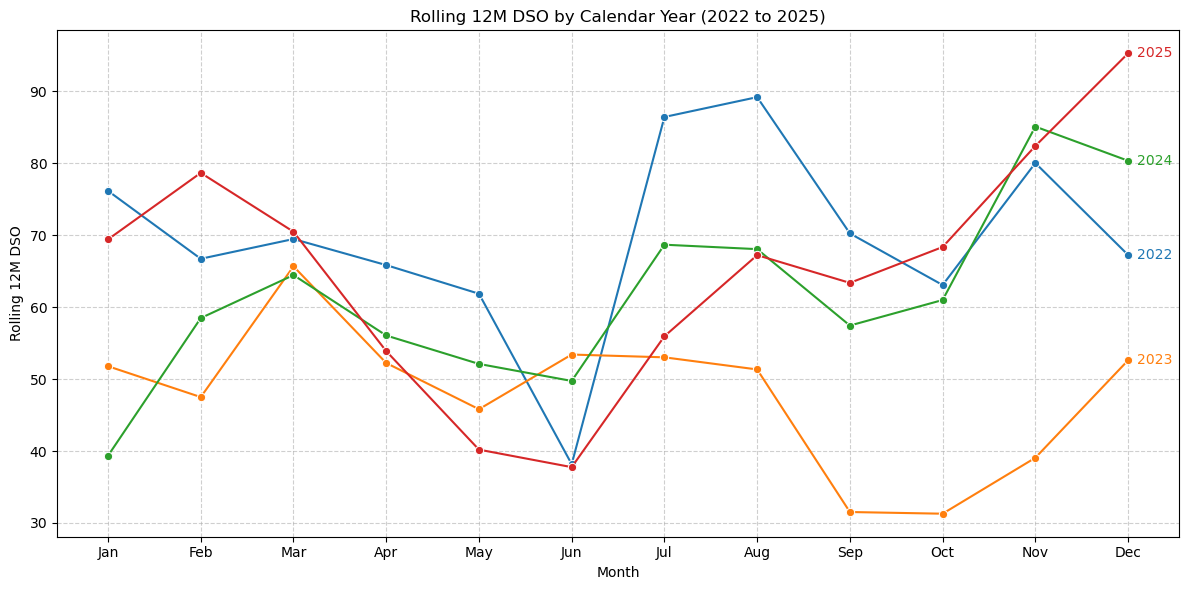

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Keep only 2022–2025
df_plot = df_dso[df_dso['year'].between(2022, 2025)]

# Plot with seaborn
plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    data=df_plot,
    x='month',
    y='rolling_12m_dso',
    hue='year',
    marker='o',
    palette='tab10',
    legend=False   # remove legend
)

# Grab the line objects in the same order seaborn plotted them
lines = ax.get_lines()
years = sorted(df_plot['year'].unique())

# Add labels at the last entry of each year
for line, year in zip(lines, years):
    group = df_plot[df_plot['year'] == year]
    last_point = group.loc[group['date'].idxmax()]  # last available date for that year
    plt.text(
        x=last_point['month'] + 0.1,   # small offset to the right
        y=last_point['rolling_12m_dso'],
        s=str(year),
        va='center',
        color=line.get_color()
    )

# Formatting
plt.title("Rolling 12M DSO by Calendar Year (2022 to 2025)")
plt.xlabel("Month")
plt.ylabel("Rolling 12M DSO")
plt.xticks(range(1, 13), 
           ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

C:\Users\rjbel\AppData\Local\Temp\ipykernel_43564\89672719.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['year_mean'] = df_plot.groupby('year')['rolling_12m_dso'].transform('mean')
C:\Users\rjbel\AppData\Local\Temp\ipykernel_43564\89672719.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['relative_pct'] = (df_plot['rolling_12m_dso'] / df_plot['year_mean']) * 100


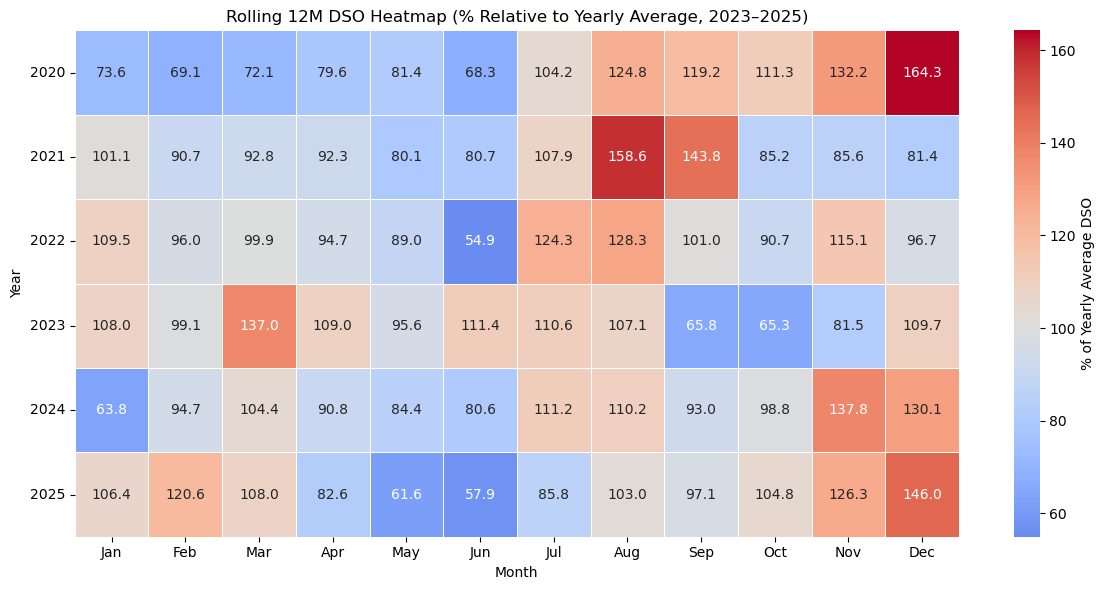

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure datetime
df_dso['date'] = pd.to_datetime(df_dso['date'])

# Extract year and month
df_dso['year'] = df_dso['date'].dt.year
df_dso['month'] = df_dso['date'].dt.month

# Keep only 2023–2025
df_plot = df_dso[df_dso['year'].between(2020, 2025)]

# Compute % relative to same year's average
df_plot['year_mean'] = df_plot.groupby('year')['rolling_12m_dso'].transform('mean')
df_plot['relative_pct'] = (df_plot['rolling_12m_dso'] / df_plot['year_mean']) * 100

# Pivot to Year x Month grid
heatmap_data = df_plot.pivot_table(
    index='year',
    columns='month',
    values='relative_pct',
    aggfunc='mean'
)

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data,
    cmap='coolwarm',       # diverging colormap
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    center=100,            # center at 100% (the yearly average)
    cbar_kws={'label': '% of Yearly Average DSO'}
)

# Formatting
plt.title("Rolling 12M DSO Heatmap (% Relative to Yearly Average, 2023–2025)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.xticks(
    ticks=[i+0.5 for i in range(12)], 
    labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
    rotation=0
)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

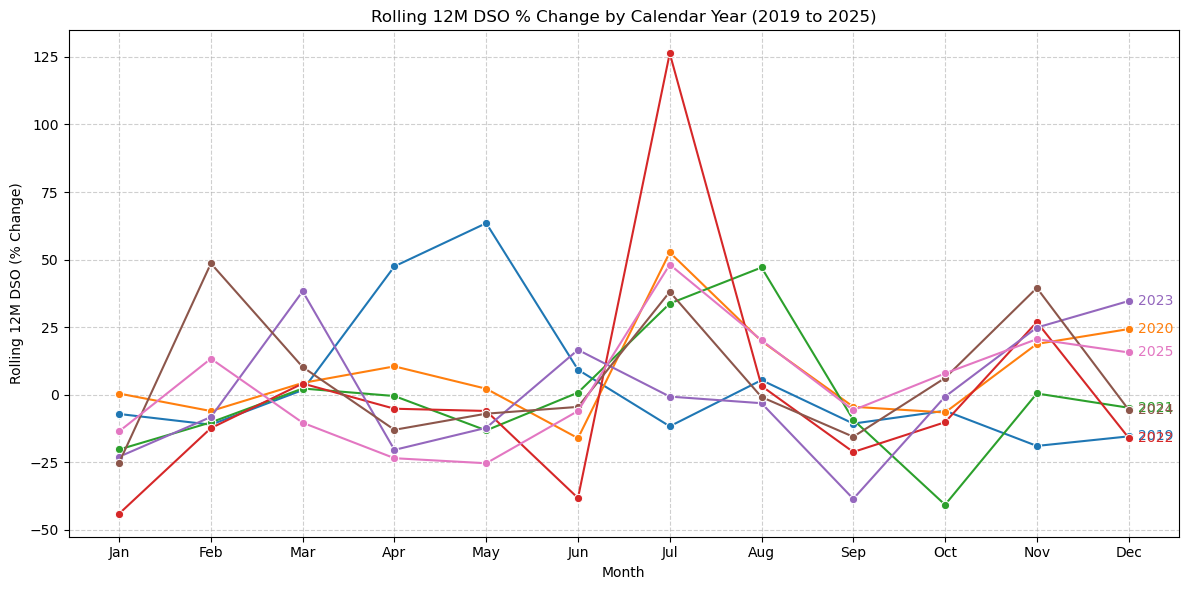

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure datetime
df_dso['date'] = pd.to_datetime(df_dso['date'])

# Extract year and month
df_dso['year'] = df_dso['date'].dt.year
df_dso['month'] = df_dso['date'].dt.month

# Filter out 2016, 2017, 2018, 2026, 2027
df_plot = df_dso[~df_dso['year'].isin([2016, 2017, 2018, 2026, 2027])]

# Plot with seaborn
plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    data=df_plot,
    x='month',
    y='rolling_12m_dso_pct_change',
    hue='year',
    marker='o',
    palette='tab10',
    legend=False   # remove 
)

# Grab the line objects in the same order seaborn plotted them
lines = ax.get_lines()
years = sorted(df_plot['year'].unique())  # ensure consistent ordering

# Add labels at the last entry of each year
for line, year in zip(lines, years):
    group = df_plot[df_plot['year'] == year]
    last_point = group.loc[group['date'].idxmax()]  # last available date for that year
    plt.text(
        x=last_point['month'] + 0.1,   # small offset to the right
        y=last_point['rolling_12m_dso_pct_change'],
        s=str(year),
        va='center',
        color=line.get_color()  # match line color
    )

# Formatting
plt.title("Rolling 12M DSO % Change by Calendar Year (2019 to 2025)")
plt.xlabel("Month")
plt.ylabel("Rolling 12M DSO (% Change)")
plt.xticks(range(1, 13), 
           ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

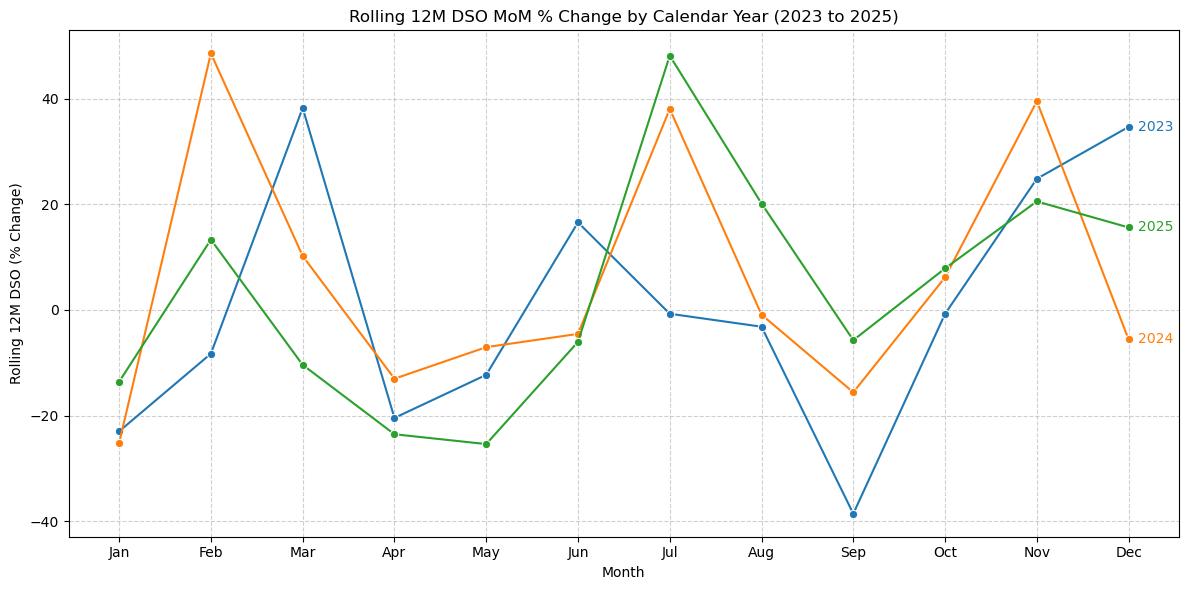

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure datetime
df_dso['date'] = pd.to_datetime(df_dso['date'])

# Extract year and month
df_dso['year'] = df_dso['date'].dt.year
df_dso['month'] = df_dso['date'].dt.month

# Keep only 2022–2025
df_plot = df_dso[df_dso['year'].between(2023, 2025)]

# Plot with seaborn
plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    data=df_plot,
    x='month',
    y='rolling_12m_dso_pct_change',
    hue='year',
    marker='o',
    palette='tab10',
    legend=False   # remove legend
)

# Grab the line objects in the same order seaborn plotted them
lines = ax.get_lines()
years = sorted(df_plot['year'].unique())

# Add labels at the last entry of each year
for line, year in zip(lines, years):
    group = df_plot[df_plot['year'] == year]
    last_point = group.loc[group['date'].idxmax()]  # last available date for that year
    plt.text(
        x=last_point['month'] + 0.1,   # small offset to the right
        y=last_point['rolling_12m_dso_pct_change'],
        s=str(year),
        va='center',
        color=line.get_color()
    )

# Formatting
plt.title("Rolling 12M DSO MoM % Change by Calendar Year (2023 to 2025)")
plt.xlabel("Month")
plt.ylabel("Rolling 12M DSO (% Change)")
plt.xticks(range(1, 13), 
           ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

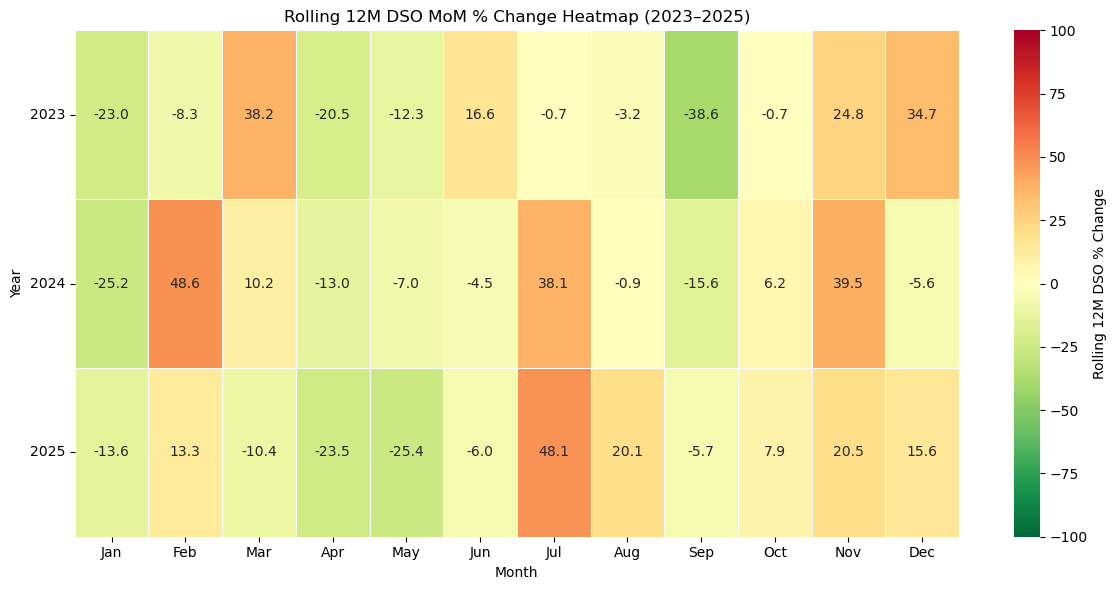

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure datetime
df_dso['date'] = pd.to_datetime(df_dso['date'])

# Extract year and month
df_dso['year'] = df_dso['date'].dt.year
df_dso['month'] = df_dso['date'].dt.month

# Keep only 2023–2025
df_plot = df_dso[df_dso['year'].between(2023, 2025)]

# Pivot to Year x Month grid
heatmap_data = df_plot.pivot_table(
    index='year',
    columns='month',
    values='rolling_12m_dso_pct_change',
    aggfunc='mean'
)

# Plot heatmap with reversed gradient
plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data,
    cmap='RdYlGn_r',   # reversed colormap
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    vmin=-100,
    vmax=100,
    center=0,
    cbar_kws={'label': 'Rolling 12M DSO % Change'}
)

# Formatting
plt.title("Rolling 12M DSO MoM % Change Heatmap (2023–2025)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.xticks(
    ticks=[i+0.5 for i in range(12)], 
    labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
    rotation=0
)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## What are the trends per plan type?

In [33]:
df_plan_a = df_all_transactions[df_all_transactions['plan_type'] == 'Plan - A' ]
df_plan_b = df_all_transactions[df_all_transactions['plan_type'] == 'Plan - B' ]
df_plan_c = df_all_transactions[df_all_transactions['plan_type'] == 'Plan - C' ]

if False:
    cs_a = CreditSales(df_plan_a)
    df_cs_a = cs_a.show_data()

    cs_b = CreditSales(df_plan_b)
    df_cs_b = cs_b.show_data()

    cs_c = CreditSales(df_plan_c)
    df_cs_c = cs_c.show_data()


dso_a = DSO(df_plan_a, df_credit_sales)
df_dso_a = dso_a.show_data()
df_dso_a['year'] = df_dso_a['date'].dt.year
df_dso_a['month'] = df_dso_a['date'].dt.month

dso_b = DSO(df_plan_b, df_credit_sales)
df_dso_b = dso_b.show_data()
df_dso_b['year'] = df_dso_b['date'].dt.year
df_dso_b['month'] = df_dso_b['date'].dt.month

dso_c = DSO(df_plan_c, df_credit_sales)
df_dso_c = dso_c.show_data()
df_dso_c['year'] = df_dso_c['date'].dt.year
df_dso_c['month'] = df_dso_c['date'].dt.month

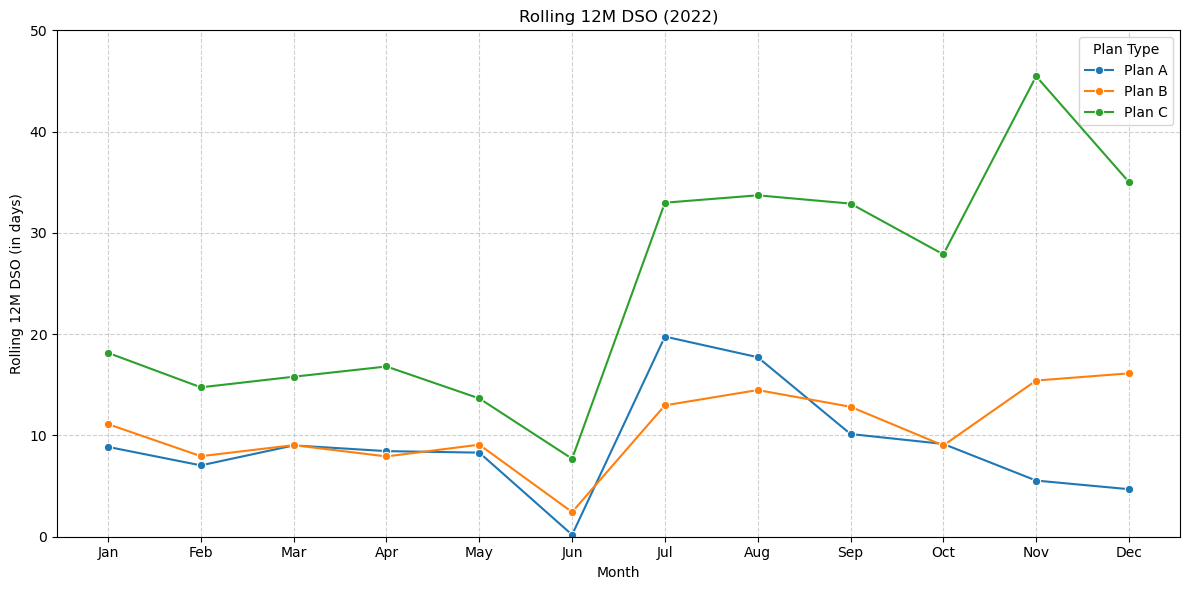

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Keep only 2022
def filter_2022(df):
    return df[(df['year'] == 2022)]

df_a_2023 = filter_2022(df_dso_a).assign(source="Plan A")
df_b_2023 = filter_2022(df_dso_b).assign(source="Plan B")
df_c_2023 = filter_2022(df_dso_c).assign(source="Plan C")

# Combine into one dataframe
df_plot = pd.concat([df_a_2023, df_b_2023, df_c_2023])

# Plot with seaborn
plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    data=df_plot,
    x='month',
    y='rolling_12m_dso',
    hue='source',      # color by plan type
    marker='o'
)

# Rename legend title
ax.legend(title="Plan Type")

# Formatting
plt.title("Rolling 12M DSO (2022)")
plt.xlabel("Month")
plt.ylabel("Rolling 12M DSO (in days)")
plt.xticks(
    range(1, 13),
    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
)
plt.ylim(0, 50)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig(r"data/eda_results/dso_per_plan_2022.png", dpi=300, bbox_inches="tight")
plt.show()

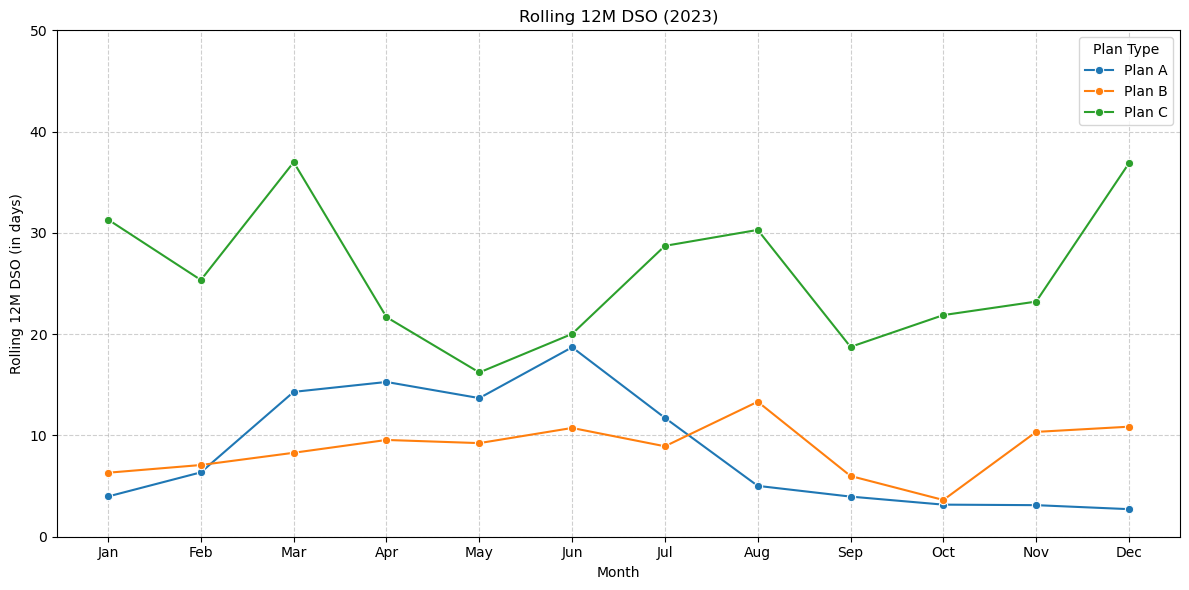

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Keep only 2023
def filter_2023(df):
    return df[(df['year'] == 2023)]

df_a_2023 = filter_2023(df_dso_a).assign(source="Plan A")
df_b_2023 = filter_2023(df_dso_b).assign(source="Plan B")
df_c_2023 = filter_2023(df_dso_c).assign(source="Plan C")

# Combine into one dataframe
df_plot = pd.concat([df_a_2023, df_b_2023, df_c_2023])

# Plot with seaborn
plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    data=df_plot,
    x='month',
    y='rolling_12m_dso',
    hue='source',      # color by plan type
    marker='o'
)

# Rename legend title
ax.legend(title="Plan Type")

# Formatting
plt.title("Rolling 12M DSO (2023)")
plt.xlabel("Month")
plt.ylabel("Rolling 12M DSO (in days)")
plt.xticks(
    range(1, 13),
    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
)
plt.ylim(0, 50)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig(r"data/eda_results/dso_per_plan_2023.png", dpi=300, bbox_inches="tight")
plt.show()

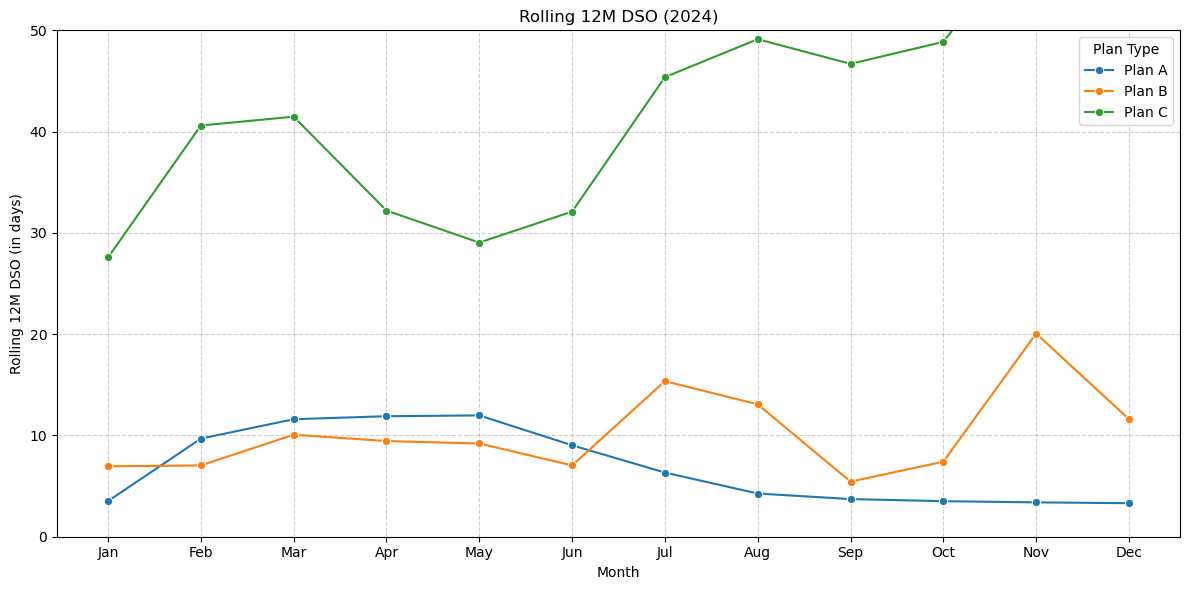

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Keep only 2024
def filter_2024(df):
    return df[(df['year'] == 2024)]

df_a_2024 = filter_2024(df_dso_a).assign(source="Plan A")
df_b_2024 = filter_2024(df_dso_b).assign(source="Plan B")
df_c_2024 = filter_2024(df_dso_c).assign(source="Plan C")

# Combine into one dataframe
df_plot = pd.concat([df_a_2024, df_b_2024, df_c_2024])

# Plot with seaborn
plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    data=df_plot,
    x='month',
    y='rolling_12m_dso',
    hue='source',      # color by plan type
    marker='o'
)

# Rename legend title
ax.legend(title="Plan Type")

# Formatting
plt.title("Rolling 12M DSO (2024)")
plt.xlabel("Month")
plt.ylabel("Rolling 12M DSO (in days)")
plt.xticks(
    range(1, 13),
    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
)
plt.ylim(0, 50)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(r"data/eda_results/dso_per_plan_2024.png", dpi=300, bbox_inches="tight")
plt.show()

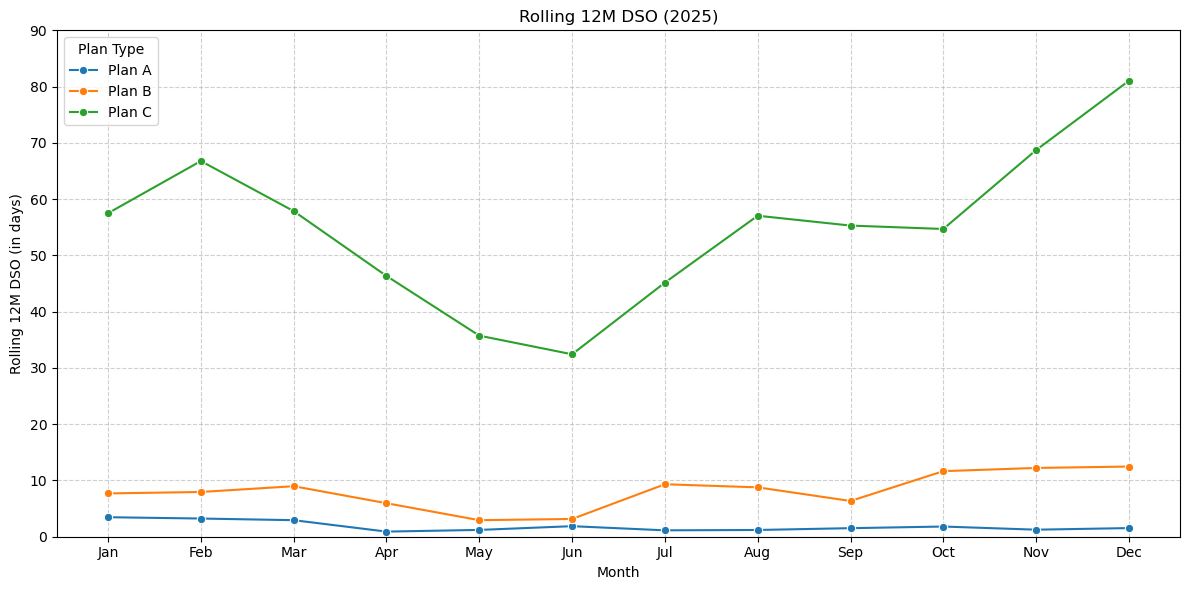

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Keep only 2025 and restrict to Jan–Oct
def filter_2025(df):
    return df[(df['year'] == 2025)]

df_a_2025 = filter_2025(df_dso_a).assign(source="Plan A")
df_b_2025 = filter_2025(df_dso_b).assign(source="Plan B")
df_c_2025 = filter_2025(df_dso_c).assign(source="Plan C")

# Combine into one dataframe
df_plot = pd.concat([df_a_2025, df_b_2025, df_c_2025])

# Plot with seaborn
plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    data=df_plot,
    x='month',
    y='rolling_12m_dso',
    hue='source',      # color by plan type
    marker='o'
)

# Rename legend title
ax.legend(title="Plan Type")

# Formatting
plt.title("Rolling 12M DSO (2025)")
plt.xlabel("Month")
plt.ylabel("Rolling 12M DSO (in days)")
plt.xticks(
    range(1, 13),  # Jan–Sep only
    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep', 'Oct', 'Nov', 'Dec']
)
plt.ylim(0, 90)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(r"data/eda_results/dso_per_plan_2025.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import pandas as pd

students = df_revenues['student_id_pseudonimized'].unique()

# Collect results in a list
results = []

for student in students:
    curr = df_revenues[df_revenues['student_id_pseudonimized'] == student]
    curr_dso = DSO(curr, df_credit_sales)
    df_curr_dso = curr_dso.show_data()
    filtered_dso = df_curr_dso[df_curr_dso['running_receivable'] < 0]
    
    if not filtered_dso.empty:
        # Add student ID as a column for clarity
        filtered_dso = filtered_dso.copy()
        filtered_dso['student_id_pseudonimized'] = student
        results.append(filtered_dso)

# Concatenate all filtered results into one DataFrame
if results:
    df_output = pd.concat(results, ignore_index=True)
    # Export to Excel
    #df_output.to_excel("negative_receivables.xlsx", index=False)

C:\Users\rjbel\Python\Notebooks\Mapua\Thesis\src\modules\feature_engineering\days_sales_outstanding.py:144: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["rolling_12m_dso_pct_change"] = df["rolling_12m_dso"].pct_change() * 100


# Analyze the distribution of days payment per invoice

In [ ]:
def label_if_on_time(row):
    row['total_late_payments'] = \
        row['30_days'] \
        + row['60_days'] \
        + row['90_days'] \
        + row['120_days'] \
        + row['150_days'] \
        + row['180_days'] \
        + row['180_above']

    if row['net_receivables'] > 0:
        label = "Not Fully Paid Yet"
    elif row['prepayments'] > 0.00 and row['total_late_payments'] == 0.00:
        label = "On Time"
    else:
        label = "Late"

    return label

df_credit_sales['is_on_time'] = df_credit_sales.apply(label_if_on_time, axis=1)

KeyError: '30_days'

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

# Filter data
df_cs_already_due = df_credit_sales[df_credit_sales["due_date"] <= datetime.today()]

# Define palette
palette = {
    'On Time': '#00b4d8', # blue
    'Late': '#fb8b24', # red
    'Not Fully Paid Yet': '#495057' # grey
}

# Plot with seaborn (seaborn will count automatically)
plt.figure(figsize=(6,4))
ax = sns.countplot(
    data=df_cs_already_due,
    x='is_on_time',
    palette=palette,
    order=['On Time', 'Late', 'Not Fully Paid Yet']  # fixed order
)

# Compute percentages for annotation
counts = df_cs_already_due['is_on_time'].value_counts()
total = counts.sum()

for i, cat in enumerate(['On Time', 'Late', 'Not Fully Paid Yet']):
    if cat in counts:
        count = counts[cat]
        percent = count / total * 100
        ax.text(i, count + counts.max()*0.01,
                f"{count} ({percent:.1f}%)",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Titles and labels
plt.title("On-Time vs Late Credit Sales", fontsize=14, fontweight='bold')
plt.xlabel("Is On Time?", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Filter for 2019–2025
# Filter not yet due
df_filtered = df_credit_sales[
    (df_credit_sales['school_year'] >= 2019) &
    (df_credit_sales['school_year'] <= 2025) &
    (df_credit_sales['due_date'] <= datetime.today())
]



# Group by school_year and is_on_time
counts = (
    df_filtered
    .groupby(['school_year', 'is_on_time'])
    .size()
    .reset_index(name='count')
)

# Compute percentages within each school_year
counts['percent'] = (
    counts.groupby('school_year')['count']
          .transform(lambda x: x / x.sum() * 100)
)

# Explicit category order
cat_order = ['On Time', 'Late', 'Not Fully Paid Yet']
counts['is_on_time'] = pd.Categorical(counts['is_on_time'], categories=cat_order, ordered=True)

# Define explicit color mapping
palette = {
    'On Time': '#00b4d8', # blue
    'Late': '#fb8b24', # red
    'Not Fully Paid Yet': '#495057' # grey
}

# Plot with percent on y-axis
plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=counts,
    x='school_year',
    y='percent',
    hue='is_on_time',
    hue_order=cat_order,
    palette=palette
)

# Add labels (percentages)
for i, row in counts.iterrows():
    x_pos = list(counts['school_year'].unique()).index(row['school_year'])
    if row['is_on_time'] == 'On Time':
        hue_offset = -0.25
    elif row['is_on_time'] == 'Late':
        hue_offset = 0
    else:
        hue_offset = 0.25
    ax.text(x_pos + hue_offset, row['percent'] + 1,
            f"{row['percent']:.1f}%", 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Titles and labels
plt.title("Credit Sales Status by School Year (2019–2025)", fontsize=14, fontweight='bold')
plt.xlabel("School Year", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.legend(title="Status", loc='upper right')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [ ]:
def label_max_days(row):
    row['total_late_payments'] = \
        row['30_days'] \
        + row['60_days'] \
        + row['90_days'] \
        + row['120_days'] \
        + row['150_days'] \
        + row['180_days'] \
        + row['180_above']

    if row['180_above'] > 0:
        label = "180_above"
    elif row['180_days'] > 0.00:
        label = "180_days"
    elif row['150_days'] > 0.00:
        label = "150_days"
    elif row['120_days'] > 0.00:
        label = "120_days"
    elif row['90_days'] > 0.00:
        label = "90_days"
    elif row['60_days'] > 0.00:
        label = "60_days"
    elif row['30_days'] > 0.00:
        label = "30_days"
    else:
        label = "On-Time"

    return label


# Filter data
df_cs_already_due = df_credit_sales[df_credit_sales["due_date"] <= datetime.today()]
df_cs_already_due['is_on_time'] = df_cs_already_due.apply(label_max_days, axis=1)

df_cs_already_due

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute counts and percentages
label_counts = df_cs_already_due['is_on_time'].value_counts()
label_percentages = (label_counts / label_counts.sum()) * 100

# Reset index for seaborn
df_plot = label_percentages.reset_index()
df_plot.columns = ['Payment Status', 'Percentage']

# Original order from your if-statements
original_order = [
    "180_above",
    "180_days",
    "150_days",
    "120_days",
    "90_days",
    "60_days",
    "30_days",
    "On-Time"
]

# Reverse the order
reversed_order = list(reversed(original_order))

# Filter to only categories that exist in the data
reversed_order = [label for label in reversed_order if label in df_plot['Payment Status'].values]

# Plot with seaborn
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=df_plot,
    x='Payment Status',
    y='Percentage',
    order=reversed_order,
    palette='Blues_d',
    hue='Payment Status'
)

# Add percentage labels on top of bars
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height(),
        f"{p.get_height():.1f}%",
        ha='center',
        va='bottom',
        fontsize=10
    )

# Formatting
ax.set_ylabel("% of invoices")
ax.set_xlabel("Payment status")
ax.set_title("When do invoices get fully paid?")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(r"Images/invoices_payment_status.png", dpi=300, bbox_inches="tight")
plt.show()